In [1]:
# 单元格 2：导入依赖与初始化
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import time
from thop import profile
import json
import importlib  # <--- 新增

# --- 关键：确保项目根目录在路径中 ---
path = os.path.join(os.getcwd(), '..', '..')
sys.path.append(path)

# --- 导入您的项目文件 ---
from utils.common_utils import printlog, set_seed, make_dir
import utils.common_params as common_params  # <--- 改为 import 整个模块
from models import LD_Net as LD_Net_Module # <--- 改为 import 整个模块
from trainTest.datasets.denoise_dataset_utils import DenoiseDataset
from trainTest.metrics.denoising_metrics import calculate_rmse, calculate_snr
from trainTest.early_stopping.early_stopping import EarlyStopping

# --- 💡 关键修正：强制重载参数和模型 ---
# 1. 强制重载 common_params，确保 C=4 生效
importlib.reload(common_params)
# 2. 确保 C=4 (双重保险)
common_params.C = 4
common_params.raw_fs = 1000
from utils.common_params import * # 重新导入到局部命名空间

# 3. 强制重载 LD_Net，确保它读取到新的 C
importlib.reload(LD_Net_Module)
from models.LD_Net import LD_Net # 重新导入类
# --- 修正结束 ---

print(f"当前参数检查: C={C}, raw_fs={raw_fs}") # 打印检查

# 设置随机种子
set_seed(seed=42)
print("所有依赖导入成功。")

当前参数检查: C=4, raw_fs=1000
所有依赖导入成功。


In [2]:
# 单元格 3：参数配置 (修正版)

# === 1. 数据集选择 ===
DATASET_NAME = "UCI"

# === 2. 超参数 (防过拟合) ===
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 200
PATIENCE = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 💡 关键防过拟合策略：L2 正则化 (权重衰减)
WEIGHT_DECAY = 1e-4

# === 3. 数据路径配置 (已更新为 步骤一 的新路径) ===
# (假设 'preProcessing' 文件夹在项目根目录)
base_data_path = os.path.join(path, "preProcessing") # path 已在单元格2中定义为根目录

siat_data_path = os.path.join(base_data_path, "SIAT_LLMD_trainData", "Denoising_TrainSet_XY")
uci_data_path = os.path.join(base_data_path, "UCI_trainData", "Denoising_TrainSet_XY")

if DATASET_NAME == "SIAT":
    data_dir = siat_data_path
    subjects_train = ['Sub01', 'Sub02', 'Sub03', 'Sub04', 'Sub05', 'Sub31', 'Sub32', 'Sub33']
    subjects_val = ['Sub34']
    subjects_test = ['Sub35']
    # 确保 common_params.py 中的 C=9
    n_channels_check = 9
else: # 默认为 "UCI"
    data_dir = uci_data_path
    subjects_train = ['1N', '2N', '3N', '4N', '5N', '7A', '8A', '9A']
    subjects_val = ['10A']
    subjects_test = ['11A']
    # 确保 common_params.py 中的 C=4
    n_channels_check = 4

# === 4. 检查参数一致性 ===
print(f"--- 训练配置: {DATASET_NAME} ---")
print(f"设备: {DEVICE}")
print(f"防过拟合 (AdamW) Weight Decay: {WEIGHT_DECAY}")
print(f"数据源: {data_dir}")
if C != n_channels_check:
    print(f"⚠️ 警告: common_params.py 中的 C={C} 与所选数据集 {DATASET_NAME} (应为 {n_channels_check}) 不匹配!")
else:
    print("✅ C 参数检查通过。")

# === 5. 模型保存路径 (已更新为您期望的路径) ===
# os.getcwd() 现在是 E:\...\LD_train Test
save_dir = os.path.join(os.getcwd(), 'checkpoints', f'LD_Net_{DATASET_NAME}')
make_dir(save_dir)
best_model_path = os.path.join(save_dir, 'ld_net_best_model.pth')
results_json_path = os.path.join(save_dir, 'test_results.json')
figure_save_path = os.path.join(save_dir, 'denoising_comparison.png')

print(f"模型将保存到: {best_model_path}")
print(f"结果将保存到: {results_json_path}")
print(f"图表将保存到: {figure_save_path}")

--- 训练配置: UCI ---
设备: cuda
防过拟合 (AdamW) Weight Decay: 0.0001
数据源: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\..\..\preProcessing\UCI_trainData\Denoising_TrainSet_XY
✅ C 参数检查通过。
模型将保存到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_UCI\ld_net_best_model.pth
结果将保存到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_UCI\test_results.json
图表将保存到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_UCI\denoising_comparison.png


In [3]:
# 单元格 4：加载数据集
print("--- 加载数据集 ---")

try:
    train_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_train, is_train=True)
    val_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_val, is_train=False)
    test_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_test, is_train=False)
except TypeError:
    # 如果您的 DenoiseDataset 不支持 is_train, 回退到 V1 版本
    print("DenoiseDataset 不支持 'is_train' 参数，已回退。")
    train_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_train)
    val_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_val)
    test_dataset = DenoiseDataset(data_dir=data_dir, subjects_list=subjects_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")
printlog("✅ 数据加载完毕。", time=True)

--- 加载数据集 ---
--- 激活训练数据增强 (V3 - Noise, Scale, Jitter, Clamp) ---
--- 正在加载 8 个受试者的数据 ---
成功加载: 1N_XY_TrainData.npz
成功加载: 2N_XY_TrainData.npz
成功加载: 3N_XY_TrainData.npz
成功加载: 4N_XY_TrainData.npz
成功加载: 5N_XY_TrainData.npz
成功加载: 7A_XY_TrainData.npz
成功加载: 8A_XY_TrainData.npz
成功加载: 9A_XY_TrainData.npz
总样本数: 3478
--- 正在加载 1 个受试者的数据 ---
成功加载: 10A_XY_TrainData.npz
总样本数: 614
--- 正在加载 1 个受试者的数据 ---
成功加载: 11A_XY_TrainData.npz
总样本数: 748
Train samples: 3478, Val samples: 614, Test samples: 748

============================================================2025-11-12 13:42:40
✅ 数据加载完毕。...



In [4]:
# 单元格 5：定义模型、损失函数、优化器 (全身修复版)

import torch
import torch.nn as nn
import torch.optim as optim
from models.LD_Net import LD_Net  # 重新导入

# 1. 实例化模型 (不管它现在认为是几通道)
model = LD_Net().to(DEVICE)
print("模型初步实例化完成。")

# --- ☢️ 终极修复：强制修正 输入、输出 和 Gain ---
try:
    # 1. 检查输入层 (model.inc.double_conv[0])
    first_layer = model.inc.double_conv[0]
    current_in_channels = first_layer.in_channels
    print(f"🔍 检查模型当前配置: 输入={current_in_channels}, 输出={model.n_out_channels}")

    if current_in_channels == 9:
        print("⚠️ 检测到模型仍为 SIAT 配置 (9通道)。正在执行全身替换手术...")

        # --- A. 替换输入层 (9 -> 4) ---
        print("  > 正在替换输入层...")
        new_in_layer = nn.Conv1d(
            in_channels=4,  # 强制改为 4
            out_channels=first_layer.out_channels,
            kernel_size=first_layer.kernel_size,
            stride=first_layer.stride,
            padding=first_layer.padding,
            bias=(first_layer.bias is not None)
        ).to(DEVICE)
        # 初始化
        nn.init.kaiming_normal_(new_in_layer.weight, mode='fan_out', nonlinearity='relu')
        model.inc.double_conv[0] = new_in_layer

        # --- B. 替换输出层 (9 -> 4) ---
        print("  > 正在替换输出层...")
        # model.outc 通常是一个 OutConv 模块，里面有一个 conv
        # 我们直接找里面的 Conv1d 并替换
        found_out_layer = False
        for name, module in model.outc.named_children():
            if isinstance(module, nn.Conv1d):
                old_out_layer = module
                new_out_layer = nn.Conv1d(
                    in_channels=old_out_layer.in_channels,
                    out_channels=4, # 强制改为 4
                    kernel_size=old_out_layer.kernel_size,
                    stride=old_out_layer.stride,
                    padding=old_out_layer.padding,
                    bias=(old_out_layer.bias is not None)
                ).to(DEVICE)
                # 初始化 (输出层通常用 Xavier 或 Kaiming)
                nn.init.xavier_normal_(new_out_layer.weight)
                if new_out_layer.bias is not None: nn.init.constant_(new_out_layer.bias, 0)

                # 替换
                setattr(model.outc, name, new_out_layer)
                found_out_layer = True
                break

        if not found_out_layer:
            print("  ⚠️ 警告: 未能在 model.outc 中找到 Conv1d，输出层可能未修正！")

        # --- C. 修正 Gain 参数 (9 -> 4) ---
        print("  > 正在修正 Gain 参数...")
        if hasattr(model, 'gain'):
            # gain 的形状通常是 [1, C, 1]
            # 我们创建一个新的 4通道 gain
            new_gain = nn.Parameter(torch.ones(1, 4, 1).to(DEVICE))
            model.gain = new_gain

        # --- D. 修正类属性 ---
        model.n_channels = 4
        model.n_out_channels = 4

        print("✅ 全身手术成功！模型已转换为 4 通道 (UCI)。")

    elif current_in_channels == 4:
        print("✅ 模型已正确初始化为 4 通道。无需修复。")
    else:
        print(f"❓ 未知通道数 {current_in_channels}，请检查代码。")

except AttributeError as e:
    print(f"⚠️ 无法自动修复模型 (结构可能不同): {e}")
    print("请手动检查 models/LD_Net.py 结构。")

# --- 修复结束 ---

print("\n损失函数在 单元格 6 中定义")

# 2. 定义优化器 (保持原有逻辑)
# --- 💡 关键改动点 B： γ (gain) 不做 weight decay ---
decay, no_decay = [], []
for name, p in model.named_parameters():
    if name.endswith('gain'):  # gamma 参数
        no_decay.append(p)
    else:
        decay.append(p)

optimizer = optim.AdamW(
    [{'params': decay, 'weight_decay': 1e-4},
     {'params': no_decay, 'weight_decay': 0.0}],
    lr=LEARNING_RATE
)
print(f"优化器: AdamW (lr={LEARNING_RATE}, weight_decay=1e-4, 'gain' 除外)")

# 3. 定义调度器
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=5
)
print("调度器: ReduceLROnPlateau (patience=5, factor=0.1)")

# 4. 定义 Early Stopping
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=best_model_path)

LD-Net (V2.4-C48-D0.2) 初始化完成。
  输入/输出通道: 9
  Dropout 概率: 0.2
  基础通道数 (base_c): 48
模型初步实例化完成。
🔍 检查模型当前配置: 输入=9, 输出=9
⚠️ 检测到模型仍为 SIAT 配置 (9通道)。正在执行全身替换手术...
  > 正在替换输入层...
  > 正在替换输出层...
  > 正在修正 Gain 参数...
✅ 全身手术成功！模型已转换为 4 通道 (UCI)。

损失函数在 单元格 6 中定义
优化器: AdamW (lr=0.001, weight_decay=1e-4, 'gain' 除外)
调度器: ReduceLROnPlateau (patience=5, factor=0.1)


In [5]:
# 单元格 6：训练与验证 (安静版 + 💡 关键修正 C：强化 loss_head)

import torch.nn.functional as F

history = {'train_loss': [], 'val_loss': [], 'lr': []}
printlog(f"--- 开始训练 {DATASET_NAME} (clean 1.0 + head 1.0 + ...) ---", time=True)
start_train_time = time.time()

eps = 1e-9

for epoch in range(EPOCHS):
    # ------------------------ 训练 ------------------------
    model.train()
    train_loss_epoch = 0.0

    for noisy_X, clean_Y in train_loader:
        x_noisy = noisy_X.to(DEVICE)
        y_true = clean_Y.to(DEVICE)

        optimizer.zero_grad()

        clean_pred, raw_noise = model(x_noisy)
        n_target = x_noisy - y_true

        # --- 💡 关键改动点 C：新复合损失 (loss_head 权重提升) ---

        loss_clean = F.l1_loss(clean_pred, y_true)

        n_target_zm = n_target - n_target.mean(dim=2, keepdim=True)
        loss_head = F.l1_loss(raw_noise, n_target_zm)

        std_p = raw_noise.std(dim=2, keepdim=True) + eps
        std_t = n_target_zm.std(dim=2, keepdim=True) + eps
        loss_var = F.l1_loss(std_p, std_t)

        loss_dc = raw_noise.mean(dim=2).abs().mean()

        num = (clean_pred * y_true).sum(dim=(1, 2), keepdim=True)
        den = (clean_pred.pow(2).sum(dim=(1, 2), keepdim=True) + eps)
        alpha = num / den
        loss_alpha = (alpha - 1.0).abs().mean()

        # 6) 总损失 (loss_head 权重从 0.5 提升到 1.0)
        loss = (1.0 * loss_clean +
                1.0 * loss_head +  # <-- 权重提升
                0.2 * loss_var +
                0.05 * loss_dc +
                0.02 * loss_alpha)
        # --- 损失结束 ---

        loss.backward()
        optimizer.step()

        train_loss_epoch += loss.item()

    train_loss = train_loss_epoch / len(train_loader)
    history['train_loss'].append(train_loss)
    current_lr = optimizer.param_groups[0]['lr']
    history['lr'].append(current_lr)

    # ------------------------ 验证 ------------------------
    model.eval()
    val_loss_epoch = 0.0
    with torch.no_grad():
        for noisy_X, clean_Y in val_loader:
            x_noisy = noisy_X.to(DEVICE)
            y_true = clean_Y.to(DEVICE)

            clean_pred, raw_noise = model(x_noisy)
            n_target = x_noisy - y_true

            # (在验证时也使用新权重)
            loss_clean = F.l1_loss(clean_pred, y_true)
            n_target_zm = n_target - n_target.mean(dim=2, keepdim=True)
            loss_head = F.l1_loss(raw_noise, n_target_zm)
            std_p = raw_noise.std(dim=2, keepdim=True) + eps
            std_t = n_target_zm.std(dim=2, keepdim=True) + eps
            loss_var = F.l1_loss(std_p, std_t)
            loss_dc = raw_noise.mean(dim=2).abs().mean()
            num = (clean_pred * y_true).sum(dim=(1, 2), keepdim=True)
            den = (clean_pred.pow(2).sum(dim=(1, 2), keepdim=True) + eps)
            alpha = num / den
            loss_alpha = (alpha - 1.0).abs().mean()

            loss = (1.0 * loss_clean +
                    1.0 * loss_head +  # <-- 权重提升
                    0.2 * loss_var +
                    0.05 * loss_dc +
                    0.02 * loss_alpha)
            # --- 损失结束 ---

            val_loss_epoch += loss.item()

    val_loss = val_loss_epoch / len(val_loader)
    history['val_loss'].append(val_loss)

    # --- 3. 打印日志 + 监控 gamma ---
    print(f"Epoch {epoch + 1:03d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.6f} | "
          f"Val Loss: {val_loss:.6f} | "
          f"LR: {current_lr:.1E}")
    with torch.no_grad():
        g = torch.nn.functional.softplus(model.gain) + 1e-3
        print(f"[Epoch {epoch + 1:03d}] gamma mean/min/max = {g.mean():.3f} / {g.min():.3f} / {g.max():.3f}")
    # --- 改动结束 ---

    # --- 4. 调度器 和 早停 ---
    scheduler.step(val_loss)
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("⚠️ 提前停止 (Early Stopping)!")
        break

total_train_time_sec = time.time() - start_train_time
printlog(f"--- 训练完成 (总用时: {total_train_time_sec / 60:.2f} 分钟) ---", time=True)
print(f"训练停止。最佳验证损失 (Best Val Loss): {early_stopping.val_loss_min:.6f}")


============================================================2025-11-12 13:42:49
--- 开始训练 UCI (clean 1.0 + head 1.0 + ...) ---...

Epoch 001/200 | Train Loss: 0.356059 | Val Loss: 0.138796 | LR: 1.0E-03
[Epoch 001] gamma mean/min/max = 1.294 / 1.294 / 1.294
Validation loss decreased (inf --> 0.138796).  Saving model ...
Epoch 002/200 | Train Loss: 0.147329 | Val Loss: 0.138506 | LR: 1.0E-03
[Epoch 002] gamma mean/min/max = 1.288 / 1.287 / 1.289
Validation loss decreased (0.138796 --> 0.138506).  Saving model ...
Epoch 003/200 | Train Loss: 0.135531 | Val Loss: 0.138237 | LR: 1.0E-03
[Epoch 003] gamma mean/min/max = 1.283 / 1.282 / 1.285
Validation loss decreased (0.138506 --> 0.138237).  Saving model ...
Epoch 004/200 | Train Loss: 0.125695 | Val Loss: 0.172821 | LR: 1.0E-03
[Epoch 004] gamma mean/min/max = 1.279 / 1.277 / 1.282
EarlyStopping counter: 1 out of 15
Epoch 005/200 | Train Loss: 0.132043 | Val Loss: 0.138183 | LR: 1.0E-03
[Epoch 005] gamma mean/min/max = 1.274 / 1.271 / 1.2

In [6]:
# 单元格 7：测试与评估 (💡 关键修正 D：兼容双输出)

printlog(f"--- 开始在测试集上评估 {DATASET_NAME} ---", time=True)

# 1. 加载模型
try:
    print(f"正在加载最佳模型 (完整对象): {best_model_path}")
    model = torch.load(best_model_path, weights_only=False)
    print("✅ 完整模型加载成功。")
except Exception as e:
    print(f"❌ 加载完整模型失败: {e}")
    raise e

model.to(DEVICE)
model.eval()

# 2. 确保 history / total_train_time_sec 存在
try:
    _ = history
    _ = total_train_time_sec
except NameError:
    print("警告: 找不到 'history' 或 'total_train_time_sec'。将使用占位值。")
    history = {}
    total_train_time_sec = -1.0

results_data = {
    "dataset": DATASET_NAME,
    "total_train_time_sec": total_train_time_sec,
    "training_history": history
}

# 3. 预分配容器
all_pred_y_tensors = []
all_clean_y_tensors = []
all_noisy_x_tensors = []

total_test_loss_baseline = 0.0
total_test_rmse_baseline = 0.0
total_test_snr_baseline = 0.0

total_test_loss = 0.0
total_test_rmse = 0.0
total_test_snr = 0.0

from trainTest.metrics.denoising_metrics import calculate_rmse, calculate_snr, collapse_check
import torch.nn.functional as F

# 打印评估时的 gamma
with torch.no_grad():
    if hasattr(model, "gain"):
        g = torch.clamp(torch.nn.functional.softplus(model.gain) + 1e-3, max=1.2)
        print(f"[Eval] gamma mean/min/max = {g.mean():.3f}/{g.min():.3f}/{g.max():.3f}")

with torch.no_grad():
    for noisy_X, clean_Y in tqdm(test_loader, desc="Testing"):
        noisy_X, clean_Y = noisy_X.to(DEVICE), clean_Y.to(DEVICE)

        # --- 💡 关键改动点 D：兼容双输出 ---
        out = model(noisy_X)
        if isinstance(out, tuple):
            predicted_Y, raw_noise = out  # 双输出：clean_pred, raw_noise
        else:
            predicted_Y = out  # 单输出：clean_pred
        # --- 修正结束 ---

        # 收集 Tensors
        all_pred_y_tensors.append(predicted_Y)
        all_clean_y_tensors.append(clean_Y)
        all_noisy_x_tensors.append(noisy_X)

        # 5) 你的 LD-Net 指标 (使用 L1 Loss)
        loss = F.l1_loss(predicted_Y, clean_Y)
        total_test_loss += loss.item()

        rmse = calculate_rmse(clean_Y, predicted_Y)
        total_test_rmse += rmse.item()

        snr = calculate_snr(clean_Y, predicted_Y)
        total_test_snr += snr.item()

        # 6) Baseline（直接用 noisy_X）
        loss_baseline = F.l1_loss(noisy_X, clean_Y)
        total_test_loss_baseline += loss_baseline.item()

        rmse_baseline = calculate_rmse(clean_Y, noisy_X)
        total_test_rmse_baseline += rmse_baseline.item()

        snr_baseline = calculate_snr(clean_Y, noisy_X)
        total_test_snr_baseline += snr_baseline.item()

# 7) 汇总平均
avg_test_loss = total_test_loss / len(test_loader)
avg_test_rmse = total_test_rmse / len(test_loader)
avg_test_snr = total_test_snr / len(test_loader)

avg_test_loss_baseline = total_test_loss_baseline / len(test_loader)
avg_test_rmse_baseline = total_test_rmse_baseline / len(test_loader)
avg_test_snr_baseline = total_test_snr_baseline / len(test_loader)

# 8) 诊断
full_pred_Y = torch.cat(all_pred_y_tensors, dim=0)
full_clean_Y = torch.cat(all_clean_y_tensors, dim=0)
full_noisy_X = torch.cat(all_noisy_x_tensors, dim=0)

print("\n--- 正在执行诊断... ---")
diag_metrics = collapse_check(full_clean_Y, full_pred_Y, full_noisy_X)

results_data["diagnostic_metrics"] = diag_metrics

# 9) 打印
print("\n--- ================== 诊断结果 ================== ---")
print(f"  Collapsed (like copy X): {diag_metrics['collapsed_like_copyX']}")
print(f"  Energy Ratio (Pred/True): {diag_metrics['energy_ratio_hat_vs_Y']:.4f}")
print(f"  Corr to Y (Target): {diag_metrics['corr_to_Y']:.4f}")
print(f"  Corr to X (Input):  {diag_metrics['corr_to_X']:.4f}")
print(f"  MSE to Y (Target): {diag_metrics['mse_to_Y']:.6f}")
print(f"  MSE to X (Input):  {diag_metrics['mse_to_X']:.6f}")

print("\n--- ================== 测试结果 ================== ---")
print(f"  数据集: {DATASET_NAME}")
print("\n  --- 性能指标 (越低越好) ---")
print(f"  L1 Loss (Baseline-噪声): {avg_test_loss_baseline:.6f}")
print(f"  L1 Loss (LD-Net-您的): {avg_test_loss:.6f} (降低了 {avg_test_loss_baseline - avg_test_loss:.6f})")
print(f"  RMSE (Baseline-噪声): {avg_test_rmse_baseline:.6f}")
print(f"  RMSE (LD-Net-您的): {avg_test_rmse:.6f} (降低了 {avg_test_rmse_baseline - avg_test_rmse:.6f})")
print("\n  --- 性能指标 (越高越好) ---")
print(f"  SNR (Baseline-噪声): {avg_test_snr_baseline:.2f} dB")
print(f"  SNR (LD-Net-您的): {avg_test_snr:.2f} dB")
print(f"  🔥 信噪比提升 (SNR Improvement): {avg_test_snr - avg_test_snr_baseline:.2f} dB 🔥")
print("--- ============================================== ---")

# 10) 保存 JSON
results_data["baseline_metrics"] = {
    "loss_l1": avg_test_loss_baseline,
    "rmse": avg_test_rmse_baseline,
    "snr_db": avg_test_snr_baseline
}
results_data["ld_net_metrics"] = {
    "loss_l1": avg_test_loss,
    "rmse": avg_test_rmse,
    "snr_db": avg_test_snr
}
results_data["snr_improvement_db"] = avg_test_snr - avg_test_snr_baseline

with open(results_json_path, 'w') as f:
    json.dump(results_data, f, indent=4)

print(f"\n✅ 完整性能指标 (及诊断) 已保存到: {results_json_path}")


============================================================2025-11-12 13:44:00
--- 开始在测试集上评估 UCI ---...

正在加载最佳模型 (完整对象): E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_UCI\ld_net_best_model.pth
✅ 完整模型加载成功。
[Eval] gamma mean/min/max = 1.164/1.108/1.200


Testing:   0%|          | 0/12 [00:00<?, ?it/s]


--- 正在执行诊断... ---

--- ================== 诊断结果 ================== ---
  Collapsed (like copy X): False
  Energy Ratio (Pred/True): 1.5599
  Corr to Y (Target): 0.8924
  Corr to X (Input):  0.9306
  MSE to Y (Target): 0.008262
  MSE to X (Input):  0.000212

--- ================== 测试结果 ================== ---
  数据集: UCI

  --- 性能指标 (越低越好) ---
  L1 Loss (Baseline-噪声): 0.060489
  L1 Loss (LD-Net-您的): 0.059388 (降低了 0.001101)
  RMSE (Baseline-噪声): 0.070746
  RMSE (LD-Net-您的): 0.067925 (降低了 0.002821)

  --- 性能指标 (越高越好) ---
  SNR (Baseline-噪声): 7.64 dB
  SNR (LD-Net-您的): 8.63 dB
  🔥 信噪比提升 (SNR Improvement): 0.99 dB 🔥
--- ============================================== ---

✅ 完整性能指标 (及诊断) 已保存到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_UCI\test_results.json


--- 可视化样本 ---
✅ 可视化图表已保存到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_UCI\denoising_comparison.png


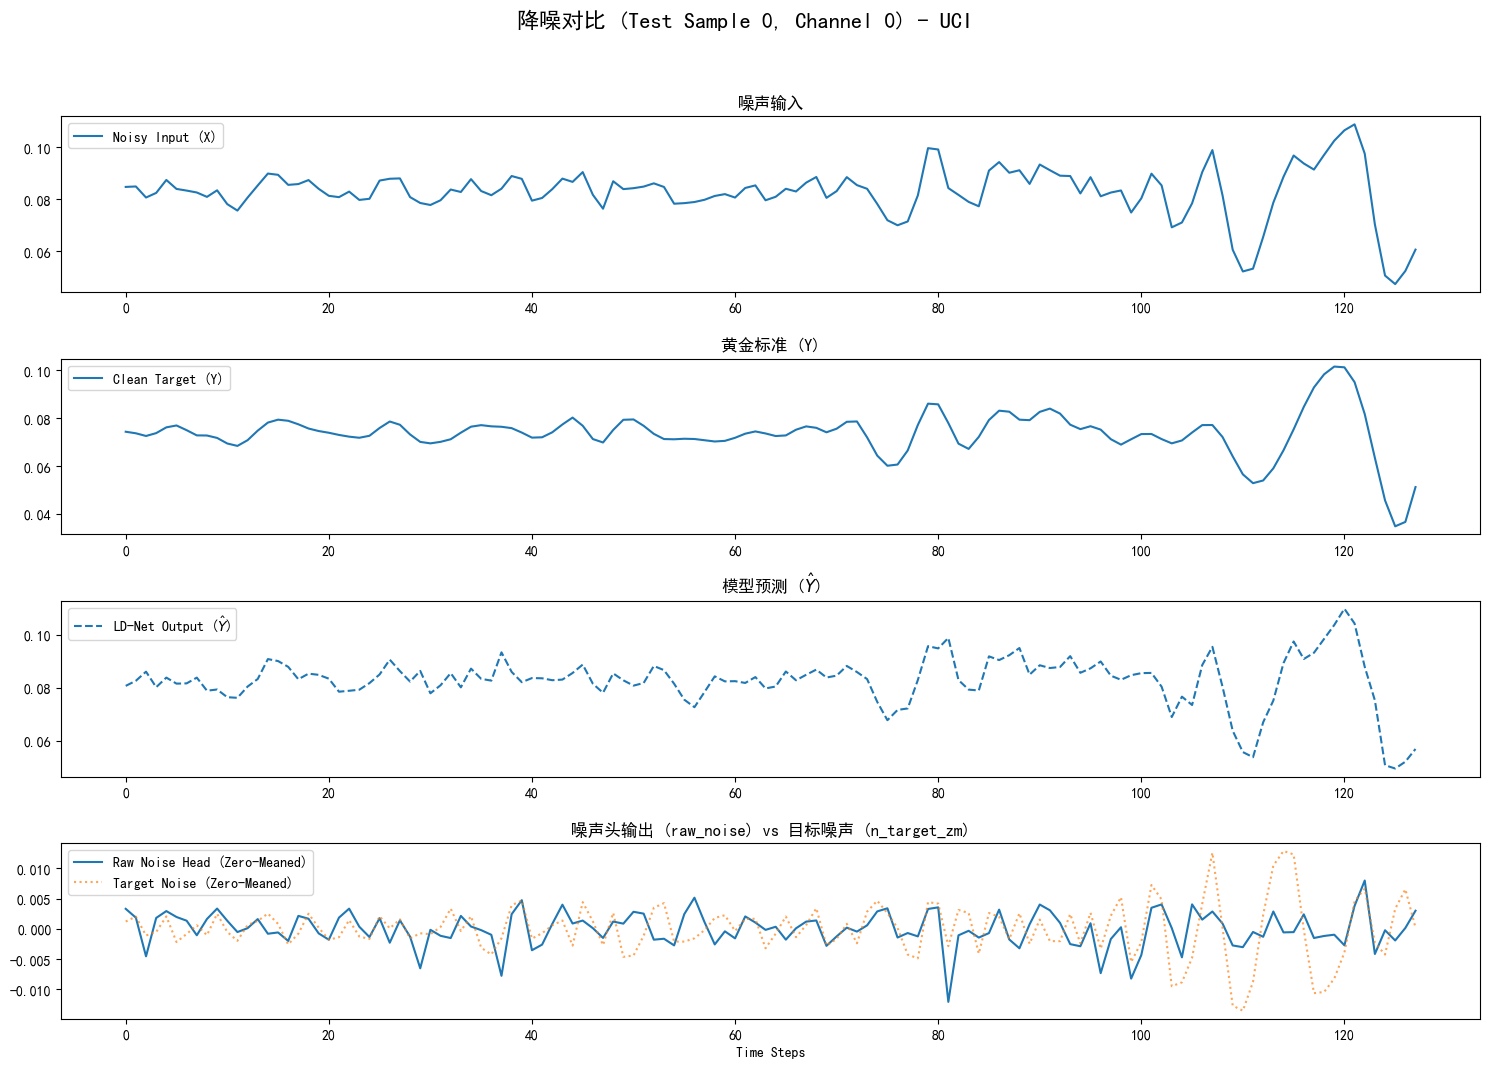

In [7]:
# 单元格 8：可视化降噪结果 (💡 关键修正 E：兼容双输出)
print("--- 可视化样本 ---")

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 中文 + 英文后备
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'dejavusans'  # 让 $\hat{Y}$ 用西文字体渲染

noisy_X_batch, clean_Y_batch = next(iter(test_loader))
noisy_X_batch = noisy_X_batch.to(DEVICE)
clean_Y_batch = clean_Y_batch.to(DEVICE)

model.eval()
with torch.no_grad():
    # --- 💡 关键改动点 E：兼容双输出 ---
    out = model(noisy_X_batch)
    if isinstance(out, tuple):
        clean_pred_batch, raw_noise_batch = out
    else:
        clean_pred_batch = out
        raw_noise_batch = None
    # --- 修正结束 ---

# 移回 CPU 并转为 numpy
noisy_X = noisy_X_batch.detach().cpu().numpy()
clean_Y = clean_Y_batch.detach().cpu().numpy()
predicted = clean_pred_batch.detach().cpu().numpy()
raw_noise = None if raw_noise_batch is None else raw_noise_batch.detach().cpu().numpy()

# 绘制第一个样本的第一通道
sample_idx, channel_idx = 0, 0
time_axis = np.arange(noisy_X.shape[2])  # (B, C, L)

n_rows = 3 if raw_noise is None else 4
plt.figure(figsize=(15, 2.8 * n_rows))
plt.suptitle(f"降噪对比 (Test Sample {sample_idx}, Channel {channel_idx}) - {DATASET_NAME}", fontsize=16)

plt.subplot(n_rows, 1, 1)
plt.plot(time_axis, noisy_X[sample_idx, channel_idx, :], label='Noisy Input (X)')
plt.legend()
plt.title("噪声输入")

plt.subplot(n_rows, 1, 2)
plt.plot(time_axis, clean_Y[sample_idx, channel_idx, :], label='Clean Target (Y)')
plt.legend()
plt.title("黄金标准 (Y)")

plt.subplot(n_rows, 1, 3)
plt.plot(time_axis, predicted[sample_idx, channel_idx, :],
         linestyle='--', label=r'LD-Net Output ($\hat{Y}$)')
plt.legend()
plt.title(r"模型预测 ($\hat{Y}$)")

# --- 💡 关键改动点 E：可视化 raw_noise ---
if raw_noise is not None:
    plt.subplot(n_rows, 1, 4)
    plt.plot(time_axis, raw_noise[sample_idx, channel_idx, :], label='Raw Noise Head (Zero-Meaned)')
    n_target_zm_np = (noisy_X[sample_idx, channel_idx, :] - clean_Y[sample_idx, channel_idx, :])
    n_target_zm_np = n_target_zm_np - n_target_zm_np.mean()
    plt.plot(time_axis, n_target_zm_np, label='Target Noise (Zero-Meaned)', linestyle=':', alpha=0.7)
    plt.legend()
    plt.title("噪声头输出 (raw_noise) vs 目标噪声 (n_target_zm)")
# --- 修正结束 ---

plt.xlabel("Time Steps")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

try:
    plt.savefig(figure_save_path, dpi=150)
    print(f"✅ 可视化图表已保存到: {figure_save_path}")
except Exception as e:
    print(f"⚠️ 未保存图像（figure_save_path 未定义或路径无效）: {e}")

plt.show()

In [8]:
# 单元格 9：复杂度与速度分析
print("--- ============ 复杂度与速度分析 ============ ---")
model.to(DEVICE).eval()

# 1. 定义一个虚拟输入 (Batch_size=1)
# (C 和 window 应该来自 common_params.py)
dummy_input_cpu = torch.randn(1, C, window).to('cpu')
dummy_input_gpu = dummy_input_cpu.to(DEVICE)

# 2. 计算参数量 (Parameters)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[1] 模型参数量 (Parameters): {total_params / 1e6:.4f} M")

# 3. 计算 MAdds (FLOPs)
madds_val = 0.0
try:
    model_cpu = model.to('cpu')
    madds, _ = profile(model_cpu, inputs=(dummy_input_cpu, ), verbose=False)
    madds_val = madds / 1e6 # MAdds in Million
    print(f"[2] 乘加运算量 (MAdds): {madds_val:.4f} M")
except Exception as e:
    print(f"[2] MAdds 计算失败 (thop可能不支持U-Net的某些操作): {e}")

# 4. 推理时间 (Inference Time) - GPU
avg_time_gpu_ms = 0.0
if DEVICE.type == 'cuda':
    model.to(DEVICE) # 确保模型在 GPU
    repetitions = 300
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    timings_gpu = np.zeros((repetitions, 1))

    # 预热
    for _ in range(50): _ = model(dummy_input_gpu)

    with torch.no_grad():
        for rep in range(repetitions):
            starter.record()
            _ = model(dummy_input_gpu)
            ender.record()
            torch.cuda.synchronize()
            timings_gpu[rep] = starter.elapsed_time(ender)

    avg_time_gpu_ms = np.sum(timings_gpu) / repetitions
    print(f"[3] GPU 单窗推理时间 (avg over {repetitions}): {avg_time_gpu_ms:.6f} ms")

# 5. 推理时间 (Inference Time) - CPU
model_cpu = model.to('cpu')
repetitions = 100
timings_cpu = np.zeros((repetitions, 1))
# 预热
for _ in range(10): _ = model_cpu(dummy_input_cpu)

with torch.no_grad():
    for rep in range(repetitions):
        start_time = time.perf_counter()
        _ = model_cpu(dummy_input_cpu)
        end_time = time.perf_counter()
        timings_cpu[rep] = (end_time - start_time) * 1000

avg_time_cpu_ms = np.sum(timings_cpu) / repetitions
print(f"[4] CPU 单窗推理时间 (avg over {repetitions}): {avg_time_cpu_ms:.6f} ms")
print("--- ============================================== ---")

# --- 加载、更新并保存复杂度指标到 JSON ---
if os.path.exists(results_json_path):
    with open(results_json_path, 'r') as f:
        results_data = json.load(f)
else:
    results_data = {}

complexity_data = {
    "params_M": total_params / 1e6,
    "madds_M": madds_val,
    "inference_time_gpu_ms": avg_time_gpu_ms,
    "inference_time_cpu_ms": avg_time_cpu_ms
}
# 将复杂度指标合并到 "ld_net_metrics" 字典中
if "ld_net_metrics" not in results_data:
    results_data["ld_net_metrics"] = {}
results_data["ld_net_metrics"].update(complexity_data)

# 将超参数也保存下来
results_data["hyperparameters"] = {
    "lr": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "weight_decay": WEIGHT_DECAY,
    "early_stop_patience": PATIENCE
}

with open(results_json_path, 'w') as f:
    json.dump(results_data, f, indent=4)

print(f"\n✅ 复杂度指标已更新到: {results_json_path}")
printlog(f"--- {DATASET_NAME} 评估全部完成! ---", line_break=True)

--- ============ 复杂度与速度分析 ============ ---
[1] 模型参数量 (Parameters): 1.5121 M
[2] 乘加运算量 (MAdds): 46.7436 M
[3] GPU 单窗推理时间 (avg over 300): 3.112754 ms
[4] CPU 单窗推理时间 (avg over 100): 2.879471 ms
--- ============================================== ---

✅ 复杂度指标已更新到: E:\基于肌电图的下肢运动模式识别\Code2\trainTest\LD_train Test\checkpoints\LD_Net_UCI\test_results.json

============================================================2025-11-12 13:44:35
--- UCI 评估全部完成! ---...

